# **EXPERIMENTO - 02 (COM PADRONIZAÇÃO - StandardScaler)**



# **Treinamento do modelo com o método "Árvore de decisão".**

In [43]:
# Importação de bibliotecas e APIs.

import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score


In [44]:
# Importação do dataset "diabetes.csv".

df = np.loadtxt("diabetes.csv", delimiter=",", skiprows=1)

In [45]:
print (df.shape)

(768, 9)


In [46]:
colunas = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
classes_outcome = ["Não diabético", "Diabético"]

In [47]:
# Criação da matriz X com as variáveis de entrada e o vetor y com a variável de saída.

X = df[:,0:8]
y = df[:,8]

In [48]:
# Separação do conjunto de treino e teste (70%/30%).

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

In [49]:
# Padronização das variáveis.

padronizacao = StandardScaler().fit(X_treino)
X_treino_padronizado = padronizacao.transform(X_treino)
X_teste_padronizado = padronizacao.transform(X_teste)

In [50]:
# Treinamento do modelo de Árvore de decisão.

clf = DecisionTreeClassifier(max_depth=3, random_state=3)
clf.fit(X_treino_padronizado, y_treino)

y_pred = clf.predict(X_teste_padronizado)

In [51]:
# Reporte da acurácia.

print (f" Acurácia: {accuracy_score(y_teste, y_pred):.4f}")

 Acurácia: 0.7186


In [52]:
# Reporte do Recall.

print (f" Recall: {recall_score (y_teste, y_pred):.4f}")

 Recall: 0.3125


In [53]:
# Reporte da precision.

print (f" Precision: {precision_score(y_teste, y_pred):.4f}")

 Precision: 0.7143


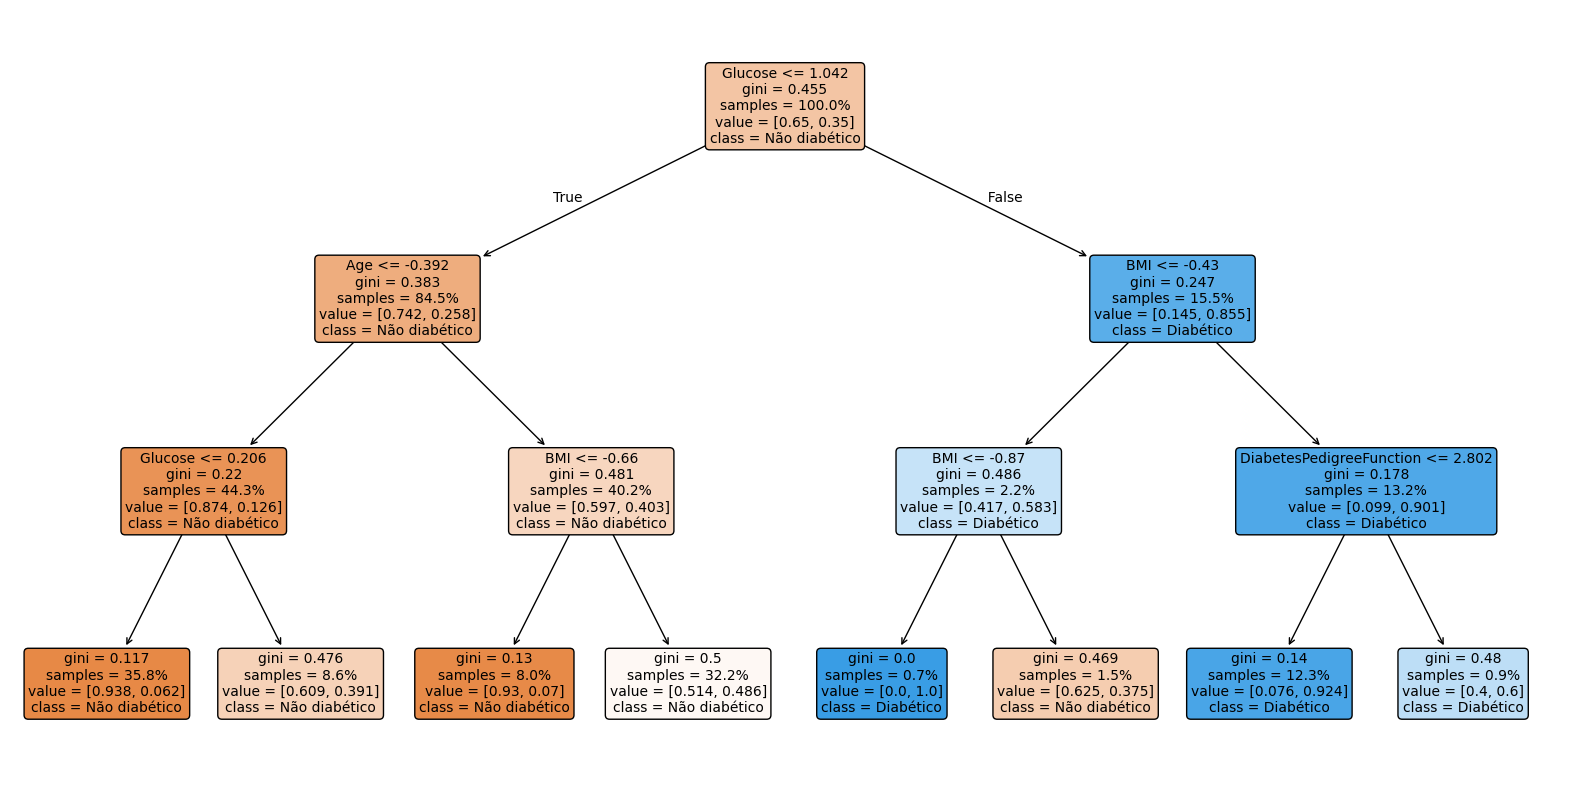

In [54]:
# Exibição da Árvore de decisão.

plt.figure(figsize=(20, 10))
tree.plot_tree(clf, proportion=True, filled=True, rounded=True, feature_names = colunas, class_names = classes_outcome, fontsize=10)
plt.show()

In [ ]:
k = (1, 5, 10, 20)

for i in k:
  print (f"\n", "k:", i, f"\n")

  clf = DecisionTreeClassifier(max_depth=i, random_state=42)
  clf.fit(X_treino_padronizado, y_treino)

  y_pred = clf.predict(X_teste_padronizado)

  print (f"Acurácia: {accuracy_score(y_teste, y_pred):.4f}" f"\n")

  print (f"Recall: {recall_score (y_teste, y_pred):.4f}", f"\n")

  print (f"Precision: {precision_score(y_teste, y_pred):.4f}", f"\n")

  plt.figure(figsize=(50, 30))
  tree.plot_tree(clf, proportion=True, filled=True, rounded=True, feature_names = colunas, class_names = classes_outcome, fontsize=10)
  plt.show()